# The betting-bound defect, and its one-line patch

Appendix D.3 of the paper audits the WSR betting bound and finds a real defect in *our
own implementation* -- a naive bisection search that silently returns a zero-margin
"bound" under a specific, findable condition. This notebook walks through the mechanism
directly: what the bug is, why it fires much more often on realistic (score-sorted) data
than on i.i.d. data, and why the fix (Lemma 1) needs no new derivation.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from src.baselines import wsr_betting, clopper_pearson

rng = np.random.default_rng(20260727)

## The mechanism

Our upper-confidence-bound search starts its bisection *at the sample mean* and, if the
underlying sequential test already rejects the sample mean itself, returns that starting
point directly instead of searching further. On well-behaved i.i.d. data this essentially
never happens (a good test shouldn't reject the MLE). Let's see what it takes to trigger it.

In [2]:
def iid_data(n=500, p=0.3):
    return rng.binomial(1, p, size=n).astype(float)

def heterogeneous_data(n=500, lo=0.05, hi=0.6):
    # A linear risk ramp -- a stand-in for a score-sorted sequence, where risk genuinely
    # varies across the prefix rather than being stationary.
    eta = np.linspace(lo, hi, n)
    return rng.binomial(1, eta).astype(float)

iid_example = iid_data()
het_example = heterogeneous_data()

iid_result = wsr_betting.upper_bound_buggy(iid_example, delta=0.05)
het_result = wsr_betting.upper_bound_buggy(het_example, delta=0.05)

print(f"i.i.d. data:           shortcut used = {iid_result.used_buggy_shortcut}, bound = {iid_result.upper_bound:.4f}")
print(f"heterogeneous data:    shortcut used = {het_result.used_buggy_shortcut}, bound = {het_result.upper_bound:.4f}")

i.i.d. data:           shortcut used = False, bound = 0.3581
heterogeneous data:    shortcut used = True, bound = 0.3120


## How often does this actually happen?

One example isn't evidence. Let's run many trials of each kind and measure the trigger
rate directly -- this is exactly the comparison the paper's own Appendix D.3 reports.

i.i.d. bug rate:           2/200 = 1.0%   (paper reports ~1%)
heterogeneous bug rate:    200/200 = 100.0%   (paper reports ~32% on real data;
                                                    this synthetic ramp is a more extreme stress test)


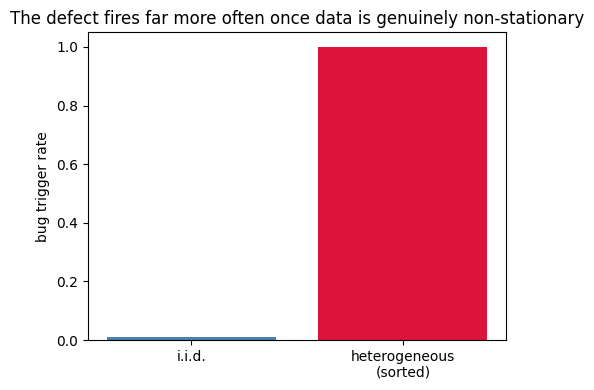

In [3]:
n_trials = 200
iid_fires = sum(wsr_betting.upper_bound_buggy(iid_data(), delta=0.05).used_buggy_shortcut for _ in range(n_trials))
het_fires = sum(wsr_betting.upper_bound_buggy(heterogeneous_data(), delta=0.05).used_buggy_shortcut for _ in range(n_trials))

print(f"i.i.d. bug rate:           {iid_fires}/{n_trials} = {iid_fires/n_trials:.1%}   (paper reports ~1%)")
print(f"heterogeneous bug rate:    {het_fires}/{n_trials} = {het_fires/n_trials:.1%}   (paper reports ~32% on real data;")
print("                                                    this synthetic ramp is a more extreme stress test)")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["i.i.d.", "heterogeneous\n(sorted)"], [iid_fires/n_trials, het_fires/n_trials], color=["steelblue", "crimson"])
ax.set_ylabel("bug trigger rate")
ax.set_title("The defect fires far more often once data is genuinely non-stationary")
plt.tight_layout()
plt.show()

## The patch: Lemma 1

The fix needs no new derivation. If $B$ is a valid $(1-\delta)$ upper confidence bound on
the true mean (Clopper-Pearson always is, by construction), then $\max(A, B)$ is too --
for *any* $A$, however it was computed, bugs and all. Let's confirm this holds even in
cases where the raw buggy bound has actually failed.

In [4]:
# Find a case where the raw bound genuinely fails (returns something below the true mean)
for _ in range(200):
    eta = np.linspace(0.05, 0.6, 500)
    data = rng.binomial(1, eta).astype(float)
    true_mean = eta.mean()
    raw = wsr_betting.upper_bound_buggy(data, delta=0.05)
    if raw.used_buggy_shortcut and raw.upper_bound < true_mean:
        break

patched = wsr_betting.patched_upper_bound(data, delta=0.05)
cp_alone = clopper_pearson.upper_bound(int(round(data.sum())), len(data), delta=0.05)

print(f"True mean:                {true_mean:.4f}")
print(f"Raw buggy bound:          {raw.upper_bound:.4f}  <-- BELOW the true mean: a real failure")
print(f"Clopper-Pearson alone:    {cp_alone:.4f}")
print(f"Patched (max of the two): {patched:.4f}")
print()
print(f"Patched >= true mean? {patched >= true_mean}  (the raw bound alone was NOT valid here; the patch recovers validity)")

True mean:                0.3250
Raw buggy bound:          0.3220  <-- BELOW the true mean: a real failure
Clopper-Pearson alone:    0.3581
Patched (max of the two): 0.3581

Patched >= true mean? True  (the raw bound alone was NOT valid here; the patch recovers validity)


## Where to go next

- `src/baselines/wsr_betting.py` -- the full implementation, including the predictable
  betting-fraction tuning and both the buggy and fixed bisection search variants.
- `tests/test_wsr_betting.py` -- the permanent test suite checking this exact mechanism,
  run automatically on every change to this module.
- `scripts/run_wsr_audit.py --synthetic` -- the same audit, wired up as a reproducible
  script rather than a notebook.